# Deep Neural Networks (PyTorch)

We're going to spend today walking through [PyTorch](https://pytorch.org), a popular open-source library for deep learning. We're talking about PyTorch because I prefer it. Others prefer TensorFlow, but that number is dwindling. Others prefer JAX, particularly in the research community, but it's a small fraction. 

In general, PyTorch has good documentation, good built-in functionality, and a wide network of compatible libraries that make Deep Learning easier to get up and running. It also exposes a bit more of the machinery to the user which makes it more customizable, particularly for things that aren't vanilla supervised learning.

There are some subtle under-the-hood differences between PyTorch and TensorFlow. I may get into those details next time, or maybe not.

In [19]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [1]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## PyTorch Tensors

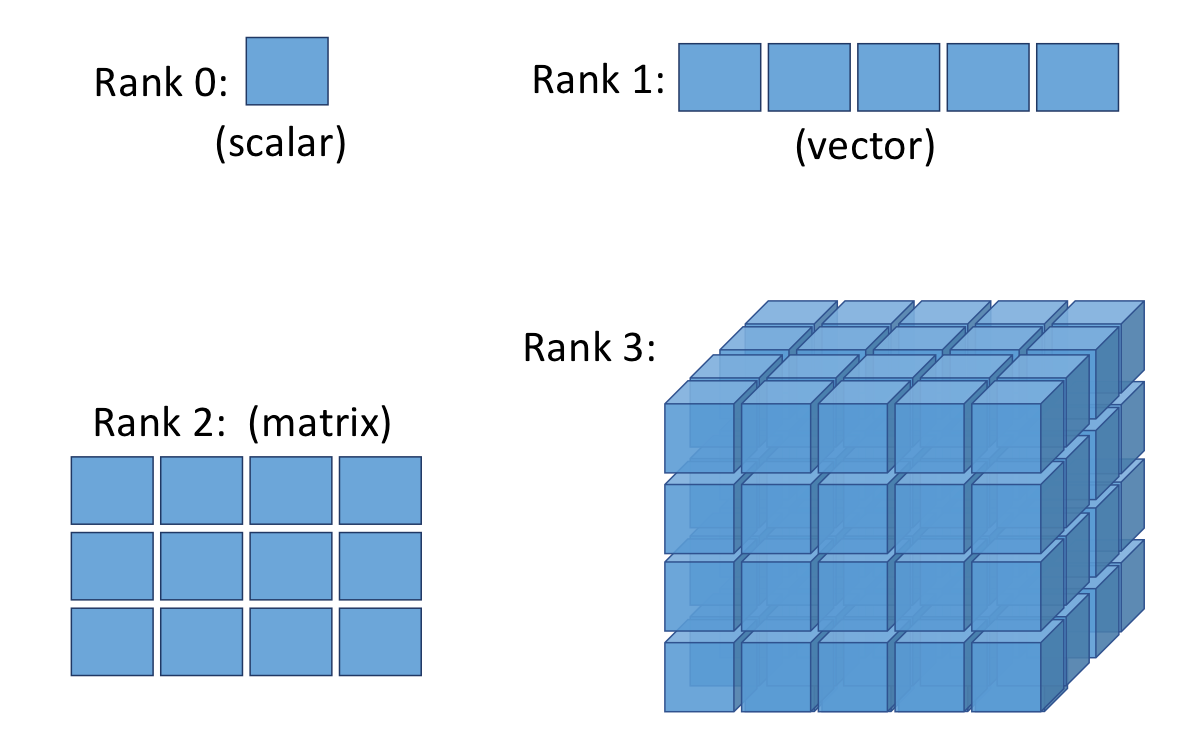

The basic unit of operation in (py)torch is a **tensor**. A tensor is a generalization of a scalar or vector. There are very precise mathematical definitions of tensors that for the purposes of this course do not really matter at all. 

On a computer, a tensor is basically a group of elements that can be indexed. A **scalar** is a rank-0 tensor. It has no index. A **vector** is a rank-1 tensor that can be indexed as $\vec{V}: V_i$. A **matrix** is a rank-2 tensor that can be indexed as $\overleftrightarrow{M}: M_{ij}$. A rank-3 tensor is similarly indexed as $T_{ijk}$.

We see tensors a lot in deep learning because we are often dealing with data structures with a particular shape and number of indices. For example, in the tutorial last week we saw how important it was to keep track of the shape and dimension of each variable in our MLP.

In [3]:
import numpy as np
a1 = [1, 2, 3]
a2 = np.array([1, 2, 3], dtype=np.float32)

t1 = torch.tensor(a1)
t2 = torch.tensor(a2)

print(t1)
print(t2)

tensor([1, 2, 3])
tensor([1., 2., 3.])


In [4]:
# Tensors are a lot like numpy ndarrays
a3 = np.eye(3, dtype=np.float32)
print(a3)
print('nd-array attributes:', a3.shape, a3.dtype)

t3 = torch.from_numpy(a3)
print(t3)
print('tensor attributes:', t3.shape, t3.dtype, t3.device, t3.grad, t3.grad_fn)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
nd-array attributes: (3, 3) float32
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
tensor attributes: torch.Size([3, 3]) torch.float32 cpu None None


In [5]:
# tensor operations
t3_1 = t3.reshape([9, 1])
print(t3_1)

t3_2 = t3.bool()
print(t3_2)

t3_3 = t3.to(torch.device('cuda'))
print(t3_3)

tensor([[1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.]])
tensor([[ True, False, False],
        [False,  True, False],
        [False, False,  True]])
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]], device='cuda:0')


### Big Tensors

Tensors can get very large and have a large number of indices. For example, a batch of images might have 4 indices: $[B, C, H, W]$

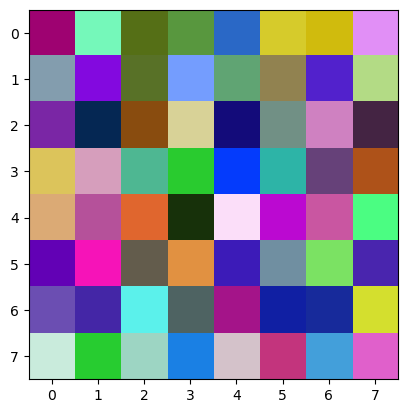

In [6]:
t_big = torch.rand(1, 3, 8, 8)

%matplotlib inline
import matplotlib.pyplot as plt
ax = plt.figure().gca()
ax.imshow(t_big.squeeze().permute(1, 2, 0))

### Fun with tensors

We can do a lot of normal mathematical and array operations with tensors just as we would numpy arrays

In [7]:
t1 = torch.rand(3, 2)
t2 = torch.normal(mean=0, std=1, size=(3, 2))

# Elementwise product
t3 = t1 * t2 # Elementwise product
print('Elementwise product', t3.shape, '\n', t3)

# Mean along dimension
print()
t4 = t1.mean(dim=1) # Mean along dimension
print('Dimension mean', t4.shape, '\n', t4)

# Matrix multiplication
print()
t5 = torch.matmul(t1.T, t2) # Matrix multiplication
t5 = t1.T @ t2 # Also matrix multiplication
t5 = torch.einsum('ki,kj->ij', t1, t2)
print('Matrix multiplication', t5.shape, '\n', t5)

# L2 Norm
print()
t6 = torch.linalg.norm(t2) # L2 norm
print('L2 norm', t6.shape, '\n', t6)

Elementwise product torch.Size([3, 2]) 
 tensor([[ 0.3603, -1.2415],
        [ 0.8269, -0.1942],
        [-0.1165,  0.7821]])

Dimension mean torch.Size([3]) 
 tensor([0.4382, 0.6599, 0.6785])

Matrix multiplication torch.Size([2, 2]) 
 tensor([[ 1.0707, -1.2727],
        [ 0.6536, -0.6535]])

L2 norm torch.Size([]) 
 tensor(3.3517)


In [8]:
print('For elements t1:', t1.shape, 'and t2:', t2.shape)

# Tensor concatenation
print()
t3 = torch.concat([t1, t2], dim=1)
print('concat(t1, t2):', t3.shape)

# Tensor splitting
print()
t4, t5 = torch.split(t3, 2, dim=1)
print('split t3 at index 2 on dimension 1:')
print('\tFirst part', t4.shape, ' = t1?', torch.all(t1 == t4))
print('\tSecond part', t5.shape, '= t2?', torch.all(t2 == t5))

# Tensor stacking
print()
t6 = torch.stack([t1, t2], dim=0)
print('stack(t1, t2):', t6.shape)

For elements t1: torch.Size([3, 2]) and t2: torch.Size([3, 2])

concat(t1, t2): torch.Size([3, 4])

split t3 at index 2 on dimension 1:
	First part torch.Size([3, 2])  = t1? tensor(True)
	Second part torch.Size([3, 2]) = t2? tensor(True)

stack(t1, t2): torch.Size([2, 3, 2])


## Torch Datasets and DataLoaders

Torch builds in a lot of functionality that we need for training neural networks beyond the networks themselves (which we will get to). For example, data loading pipelines to serve tensors to the model during training

In [9]:
from torch.utils.data import Dataset
class BasicDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        """ So torch code knows how many examples to fetch from the dataset """
        return self.x.shape[0]

    def __getitem__(self, idx):
        """ So torch code knows how to access the underlying data """
        return self.x[idx], self.y[idx]

# A torch Dataset can be accessed just like an array now
dataset = BasicDataset(
    x=torch.rand([10, 4]),
    y=torch.arange(10, dtype=torch.long)
)

print(f"The size of the dataset is {len(dataset)}")
print(f"The 4th element of the dataset is {dataset[3]}")

The size of the dataset is 10
The 4th element of the dataset is (tensor([0.3786, 0.9752, 0.2748, 0.3427]), tensor(3))


In [10]:
from torch.utils.data import TensorDataset

tensor_dataset = TensorDataset(dataset.x, dataset.y)
print(f"The size of the dataset is {len(dataset)}")
print(f"The 4th element of the dataset is {dataset[3]}")

The size of the dataset is 10
The 4th element of the dataset is (tensor([0.3786, 0.9752, 0.2748, 0.3427]), tensor(3))


In [11]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset=dataset, batch_size=2, shuffle=True)
for ii, batch in enumerate(loader):
    print(f"Batch {ii}: x={batch[0]}\n\t y={batch[1]}")

Batch 0: x=tensor([[0.2102, 0.4417, 0.8518, 0.6464],
        [0.8176, 0.1619, 0.1667, 0.5543]])
	 y=tensor([5, 8])
Batch 1: x=tensor([[0.3488, 0.3828, 0.6688, 0.1512],
        [0.4493, 0.7629, 0.7231, 0.4080]])
	 y=tensor([0, 6])
Batch 2: x=tensor([[0.0314, 0.8009, 0.9072, 0.5899],
        [0.5992, 0.6978, 0.3422, 0.1404]])
	 y=tensor([2, 4])
Batch 3: x=tensor([[0.3786, 0.9752, 0.2748, 0.3427],
        [0.9983, 0.7704, 0.9194, 0.4316]])
	 y=tensor([3, 9])
Batch 4: x=tensor([[0.5065, 0.6795, 0.7795, 0.6141],
        [0.3948, 0.0342, 0.6437, 0.6550]])
	 y=tensor([1, 7])


In [12]:
for epoch in range(2):
    print(f"Epoch {epoch}")
    for ii, batch in enumerate(loader):
        print(f"\tBatch {ii}: x={batch[0]}\n\t\t y={batch[1]}")

Epoch 0
	Batch 0: x=tensor([[0.8176, 0.1619, 0.1667, 0.5543],
        [0.9983, 0.7704, 0.9194, 0.4316]])
		 y=tensor([8, 9])
	Batch 1: x=tensor([[0.3948, 0.0342, 0.6437, 0.6550],
        [0.5065, 0.6795, 0.7795, 0.6141]])
		 y=tensor([7, 1])
	Batch 2: x=tensor([[0.2102, 0.4417, 0.8518, 0.6464],
        [0.0314, 0.8009, 0.9072, 0.5899]])
		 y=tensor([5, 2])
	Batch 3: x=tensor([[0.3786, 0.9752, 0.2748, 0.3427],
        [0.4493, 0.7629, 0.7231, 0.4080]])
		 y=tensor([3, 6])
	Batch 4: x=tensor([[0.5992, 0.6978, 0.3422, 0.1404],
        [0.3488, 0.3828, 0.6688, 0.1512]])
		 y=tensor([4, 0])
Epoch 1
	Batch 0: x=tensor([[0.3488, 0.3828, 0.6688, 0.1512],
        [0.9983, 0.7704, 0.9194, 0.4316]])
		 y=tensor([0, 9])
	Batch 1: x=tensor([[0.3948, 0.0342, 0.6437, 0.6550],
        [0.2102, 0.4417, 0.8518, 0.6464]])
		 y=tensor([7, 5])
	Batch 2: x=tensor([[0.3786, 0.9752, 0.2748, 0.3427],
        [0.5992, 0.6978, 0.3422, 0.1404]])
		 y=tensor([3, 4])
	Batch 3: x=tensor([[0.4493, 0.7629, 0.7231, 0.4

### Multiprocessing while data loading

In [13]:
import os
print(f'Environment has {os.cpu_count()} available cores')

Environment has 32 available cores


In [14]:
dataset = TensorDataset(
    torch.rand([8192, 3, 128, 128]),
    torch.arange(8192, dtype=torch.long)
)
print(len(dataset))

8192


In [15]:
from time import time
loader = DataLoader(dataset, batch_size=32, num_workers=0)
for epoch in range(5):
    t = time()
    for ii, batch in enumerate(loader):
        batch_size = len(batch[0])
    print(f"Epoch {epoch}: {time()-t:.3f} s")

Epoch 0: 3.998 s
Epoch 1: 3.197 s
Epoch 2: 2.904 s
Epoch 3: 4.698 s
Epoch 4: 3.696 s


In [16]:
from time import time
loader = DataLoader(dataset, batch_size=32, num_workers=2, persistent_workers=True)
for epoch in range(5):
    t = time()
    for ii, batch in enumerate(loader):
        batch_size = len(batch[0])
    print(f"Epoch {epoch}: {time()-t:.3f} s")

Epoch 0: 1.514 s
Epoch 1: 0.498 s
Epoch 2: 0.494 s
Epoch 3: 0.490 s
Epoch 4: 0.510 s


## Gradient descent

### Linear regression

Just as a teaser, let's see how to do regression using gradient descent and PyTorch. Start by creating a dataset in numpy

[Text(0.5, 0, 'x'), Text(0, 0.5, 'y')]

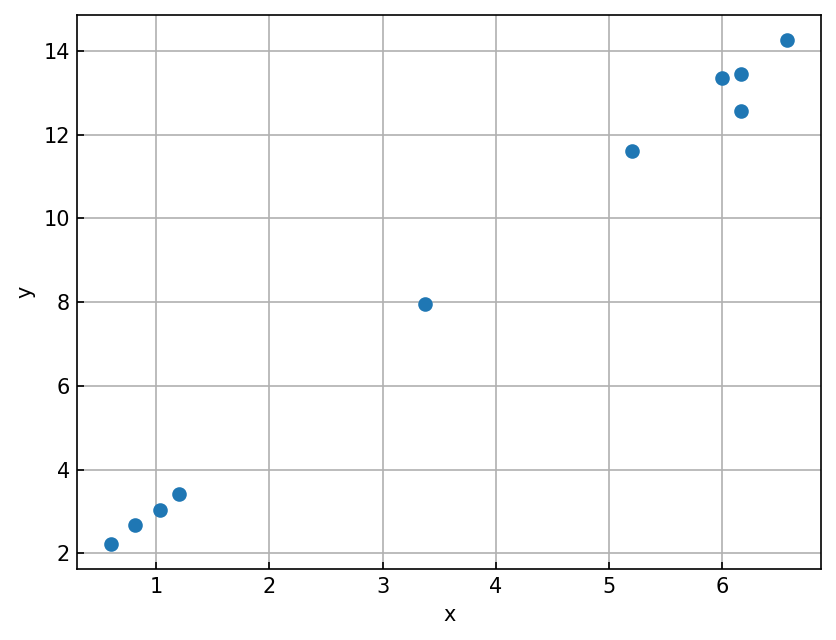

In [20]:
X = np.random.uniform(size=(10, 1)).astype(np.float32) * 10
noise = np.random.normal(0, 0.25, size=X.shape).astype(np.float32)

y = 2. * X + 1. + noise

ax = plt.figure().gca()
ax.scatter(X, y)
ax.set(xlabel='x', ylabel='y')

In [22]:
# Convert the numpy array into a PyTorch Dataset
from torch.utils.data import TensorDataset, DataLoader
X_train = torch.from_numpy(X)
y_train = torch.from_numpy(y)

# A dataset holds the torch tensors
train_dataset = TensorDataset(X_train, y_train)

# A dataloader serves up the data to the model
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

In [27]:
# Initialize the model weights
slope = torch.randn(1)
slope.requires_grad_() # We want to compute gradients for this parameter

intercept = torch.zeros(1, requires_grad=True)

def mse_loss(y_true, y_pred):
    return (y_true - y_pred).pow(2).mean()

def model(x):
    return x @ slope + intercept

lr = 0.01
num_epochs = 100
log_epochs = 10

for epoch in range(num_epochs):
    epoch_loss = 0.
    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch)
        loss = mse_loss(y_batch, y_pred)

        loss.backward() # This computes the gradients for our relevant tensors

        with torch.no_grad(): # We don't track gradients when updating weights now
            slope -= lr * slope.grad
            intercept -= lr * intercept.grad

            slope.grad.zero_()
            intercept.grad.zero_()
        epoch_loss += loss.item()

    if epoch % log_epochs == 0:
        print(f"Epoch {epoch}: loss = {epoch_loss:.3f}")

Epoch 0: loss = 313.988
Epoch 10: loss = 2.015
Epoch 20: loss = 1.743
Epoch 30: loss = 1.914
Epoch 40: loss = 1.531
Epoch 50: loss = 1.611
Epoch 60: loss = 1.673
Epoch 70: loss = 1.253
Epoch 80: loss = 1.867
Epoch 90: loss = 1.697


Fit parameters: slope = 1.902, intercept = 1.044


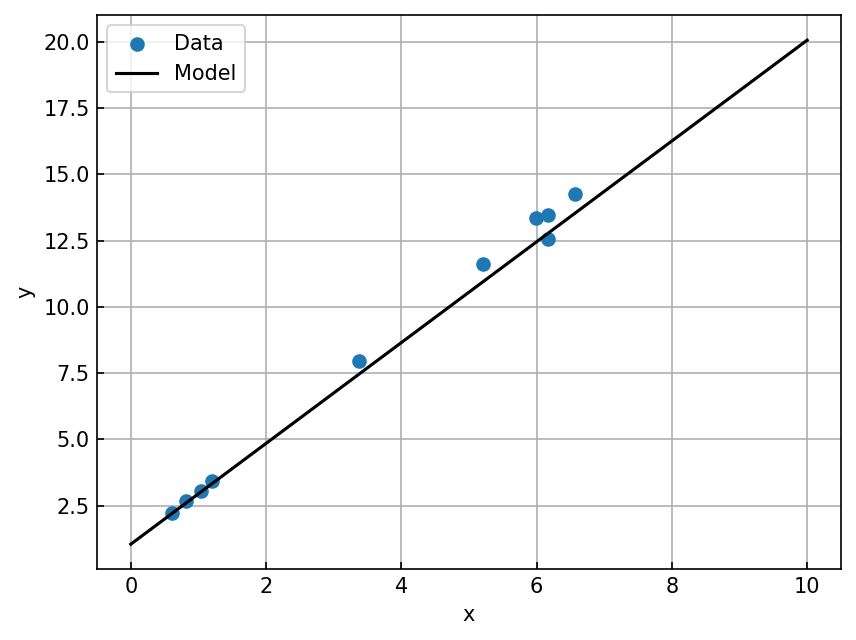

In [28]:
print(f"Fit parameters: slope = {slope.item():.3f}, intercept = {intercept.item():.3f}")

ax = plt.figure().gca()
ax.scatter(X, y, label='Data')

xx = torch.linspace(0, 10, 5, dtype=torch.float32, requires_grad=False)
yy = model(xx[:, None])
ax.plot(xx.numpy(), yy.detach().numpy(), color='black', label='Model')

ax.set(xlabel='x', ylabel='y');
ax.legend()

#### How does this work?

PyTorch stores an attribute alongside each tensor called `grad`. We'll talk about this next class in more detail. But in a nutshell, this piece is populated when we call `backward()` after making the forward pass. 

In [30]:
# Initialize the model weights
slope = torch.randn(1, requires_grad=True)
intercept = torch.zeros(1, requires_grad=True)

for x_batch, y_batch in train_loader:
    print(slope.grad, intercept.grad)

    y_pred = model(x_batch)
    print(slope.grad, intercept.grad)

    loss = mse_loss(y_batch, y_pred)
    print(slope.grad, intercept.grad)

    loss.backward() # This computes the gradients for our relevant tensors
    print(slope.grad, intercept.grad)

    break

None None
None None
None None
tensor([-4.2694]) tensor([-4.1380])


#### A more `PyTorch` way of doing it

In [31]:
# Or we can do this using `torch.nn` and its associated machinery
model = torch.nn.Linear(X_train.shape[1], y_train.shape[0], bias=True).to(device)
loss = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(num_epochs):
    epoch_loss = 0.
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        y_pred = model(x_batch)[:, 0]
        loss = mse_loss(y_batch, y_pred)

        loss.backward() # This computes the gradients for our relevant tensors
        optimizer.step() # Apply the gradient update to parameters
        optimizer.zero_grad() # Reset all gradients

        epoch_loss += loss.item()

    if epoch % log_epochs == 0:
        print(f"Epoch {epoch}: loss = {epoch_loss:.3f}")

Epoch 0: loss = 237.534
Epoch 10: loss = 0.850
Epoch 20: loss = 1.212
Epoch 30: loss = 1.682
Epoch 40: loss = 1.523
Epoch 50: loss = 1.376
Epoch 60: loss = 0.953
Epoch 70: loss = 1.544
Epoch 80: loss = 1.243
Epoch 90: loss = 1.765


Fit parameters: slope = 0.937, intercept = 0.000


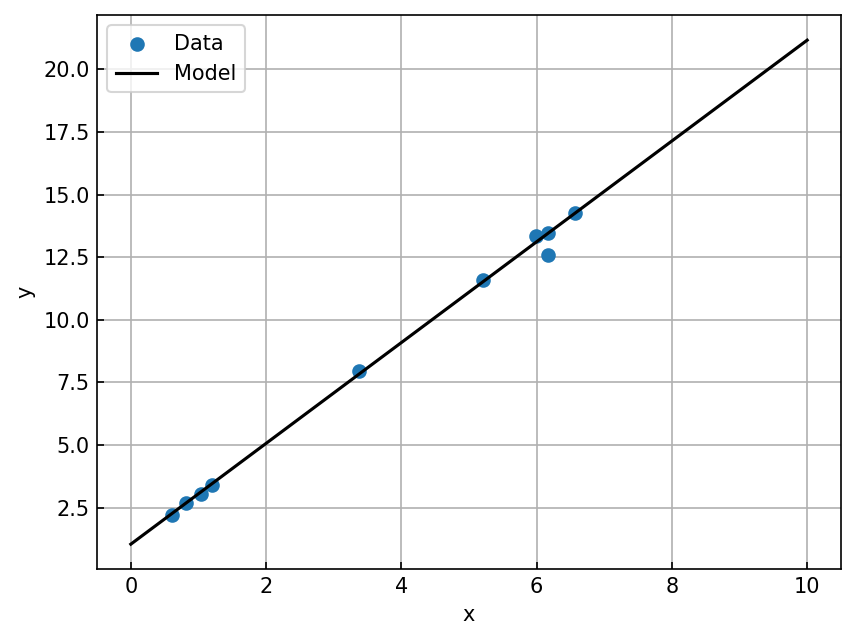

In [32]:
print(f"Fit parameters: slope = {slope.item():.3f}, intercept = {intercept.item():.3f}")

ax = plt.figure().gca()
ax.scatter(X, y, label='Data')

with torch.no_grad():
    xx = torch.linspace(0, 10, 5, dtype=torch.float32, device=device)
    yy = model(xx[:, None])[:, 0]
    ax.plot(xx.cpu().numpy(), yy.cpu().numpy(), color='black', label='Model')

ax.set(xlabel='x', ylabel='y');
ax.legend()

### Polynomial regression

How would you implement a model to fit the following dataset?

[Text(0.5, 0, 'x'), Text(0, 0.5, 'y')]

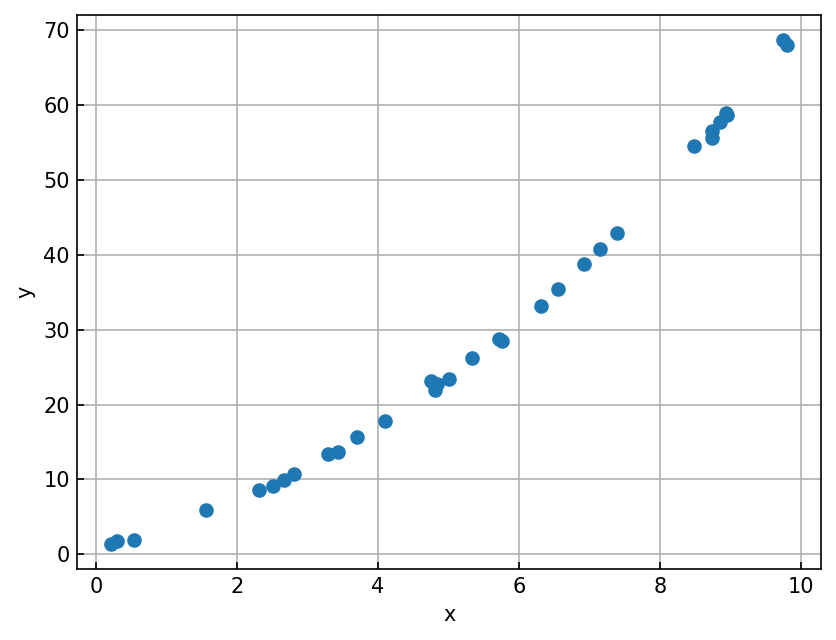

In [33]:
X = np.random.uniform(size=(32, 1)).astype(np.float32) * 10
noise = np.random.normal(0, 0.5, size=X.shape).astype(np.float32)

y = 0.5 * X**2 + 2. * X + 1. + noise

ax = plt.figure().gca()
ax.scatter(X, y)
ax.set(xlabel='x', ylabel='y')

## Neural networks

Let's train a neural network to fit the XOR dataset

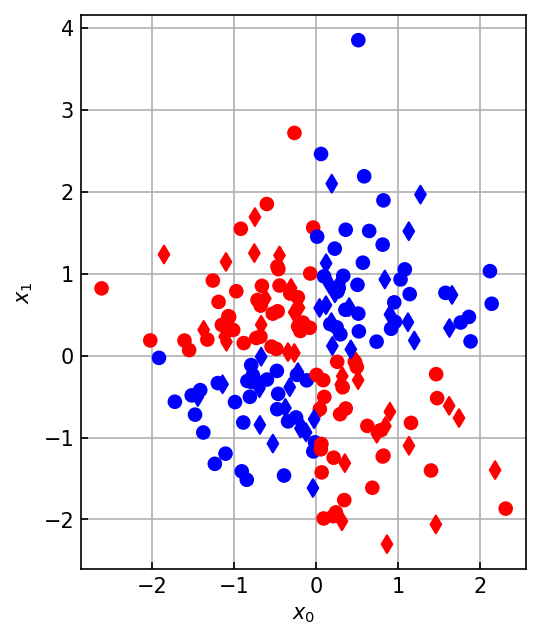

In [61]:
def make_xor_dataset(N=100, random_seed=42):
    np.random.seed(random_seed)
    X = np.random.randn(N, 2).astype(np.float32)
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    y = np.where(y, 1, 0)
    return X, y

X, y = make_xor_dataset(N=128, random_seed=42)
X_test, y_test = make_xor_dataset(N=64, random_seed=1)

ax = plt.figure().gca()
ax.scatter(X[:, 0], X[:, 1], c=y, marker='o', cmap='bwr')
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='d', cmap='bwr')
ax.set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal');

In [62]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
train_dataset, val_dataset = random_split(dataset, (0.8, 0.2))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)

Train: 103, Val: 25, Test: 64


In [63]:
class Model(torch.nn.Module):
    """ A torch.nn.Module object implements a forward pass
        Torch, under the hood, takes care of everything else
    """
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = torch.nn.functional.sigmoid(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

model = Model(
    input_size=X.shape[1],
    hidden_size=128,
    output_size=2, # 2 classes
).to(device)
model

Model(
  (hidden_layer): Linear(in_features=2, out_features=128, bias=True)
  (output_layer): Linear(in_features=128, out_features=2, bias=True)
)

In [64]:
def train(model, loss_fn, optimizer, train_loader, val_loader, max_epochs=500):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    for epoch in range(max_epochs):
        train_loss.append(0)
        train_acc.append(0)
        for x, y, in train_loader:
            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss[-1] += loss.item() * x.shape[0]
            train_acc[-1]  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

        train_loss[-1] /= len(train_dataset)
        train_acc[-1] /= len(train_dataset)

        val_loss.append(0)
        val_acc.append(0)
        with torch.no_grad():
            for x, y, in val_loader:
                x = x.to(device)
                y = y.to(device)

                y_pred = model(x)
                loss = loss_fn(y_pred, y)

                val_loss[-1] += loss.item() * x.shape[0]
                val_acc[-1]  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

            val_loss[-1] /= len(val_dataset)
            val_acc[-1] /= len(val_dataset)

    return model, (train_loss, train_acc, val_loss, val_acc)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model, model_stats = train(model, loss_fn, optimizer, train_loader, val_loader)

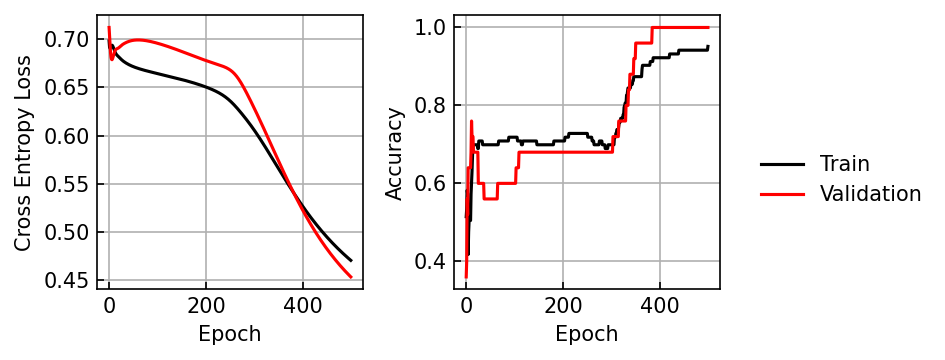

In [65]:
def loss_accuracy_plot(train_loss, train_acc, val_loss, val_acc):
    fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

    ax[0].plot(train_loss, color='black', label='Train')
    ax[0].plot(val_loss, color='red', label='Validation')
    ax[0].set(xlabel='Epoch', ylabel='Cross Entropy Loss')

    ax[1].plot(train_acc, color='black', label='Train')
    ax[1].plot(val_acc, color='red', label='Validation')
    ax[1].set(xlabel='Epoch', ylabel='Accuracy')

    fig.legend(*ax[1].get_legend_handles_labels(), 
            loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)
    return fig

loss_accuracy_plot(*model_stats)
plt.tight_layout()

<Axes: >

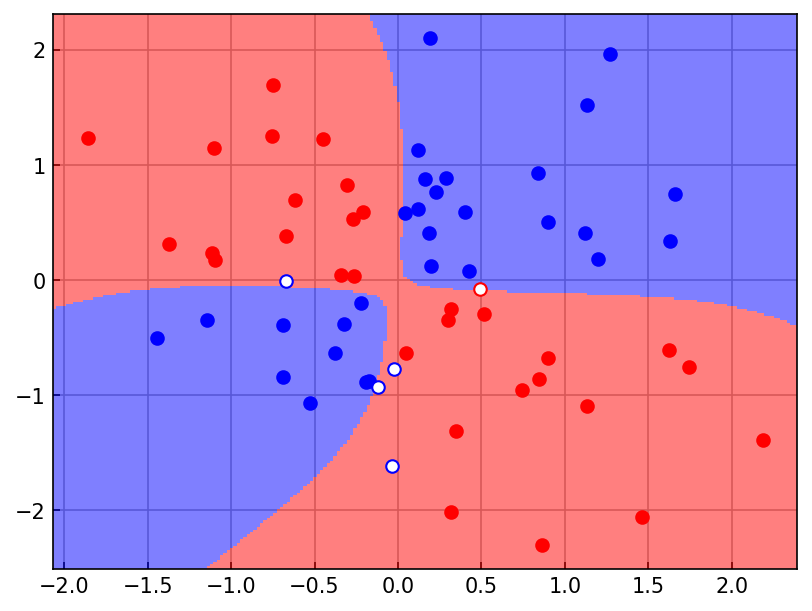

In [66]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red']):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    with torch.no_grad():
        x_grid = np.stack([x1.ravel(), x2.ravel()]).T
        x_grid = torch.from_numpy(x_grid.astype(np.float32)).to(device)
        y_model = model(x_grid).cpu().numpy()
        y_model = np.argmax(y_model, axis=-1)
        y_model = y_model.reshape(x1.shape)

        y_pred = model(torch.from_numpy(X).to(device)).cpu().numpy()
        y_pred = np.argmax(y_pred, axis=1)

        pred_mask = y_pred == y

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        label_mask = y == label
        ax.scatter(X[label_mask & pred_mask, 0], X[label_mask & pred_mask, 1], 
                   facecolor=colors[label], edgecolor=colors[label])
        ax.scatter(X[label_mask & ~pred_mask, 0], X[label_mask & ~pred_mask, 1], 
                   facecolor='white', edgecolor=colors[label])
    return ax

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

## Activation functions

In [75]:
class LinearModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

class TanhModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = torch.nn.functional.tanh(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

class ReLUModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = torch.nn.functional.relu(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

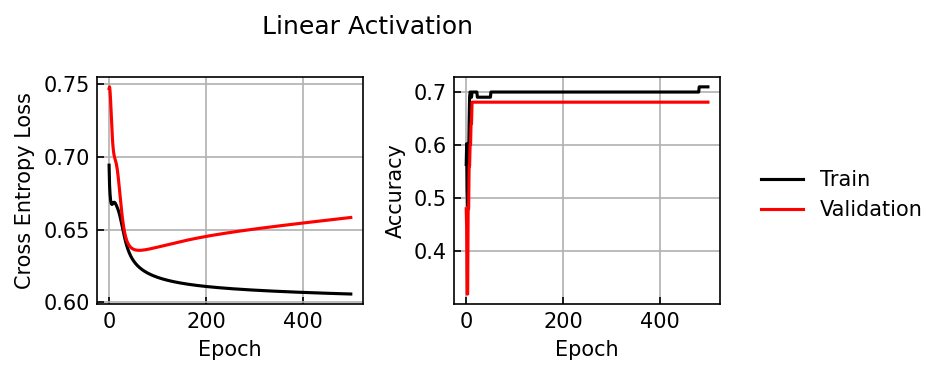

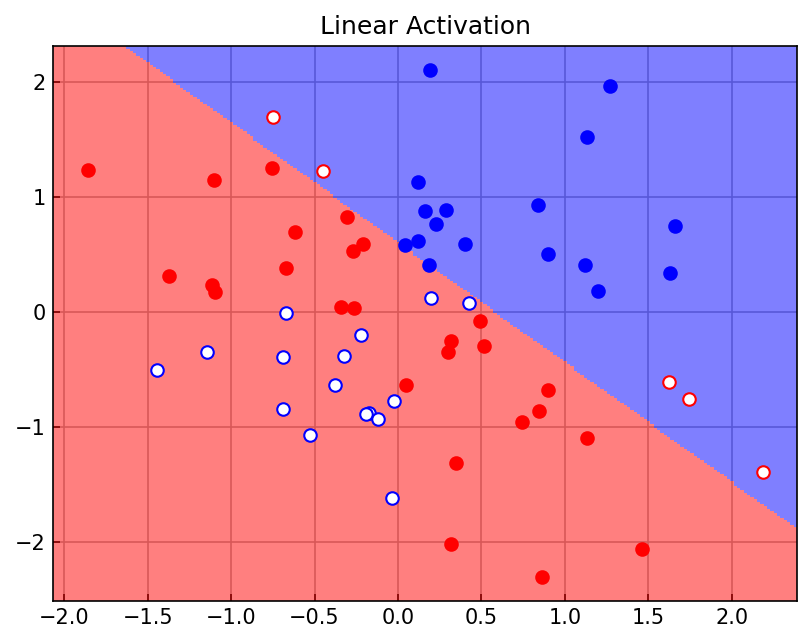

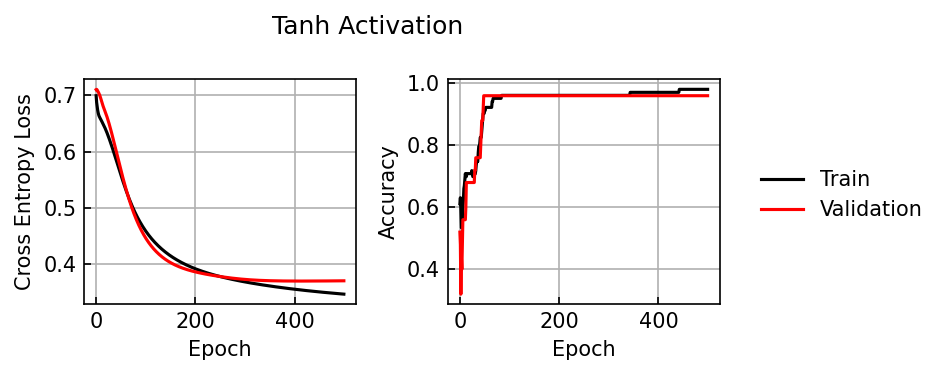

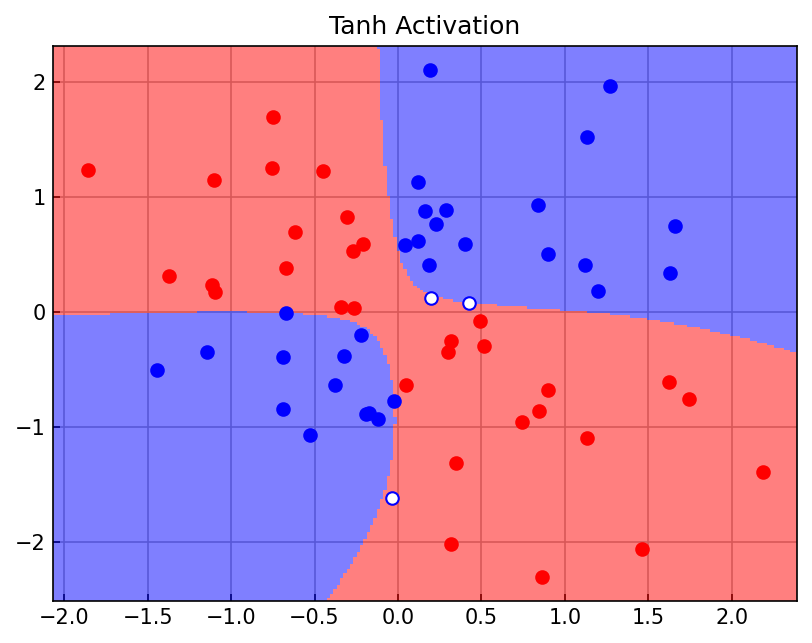

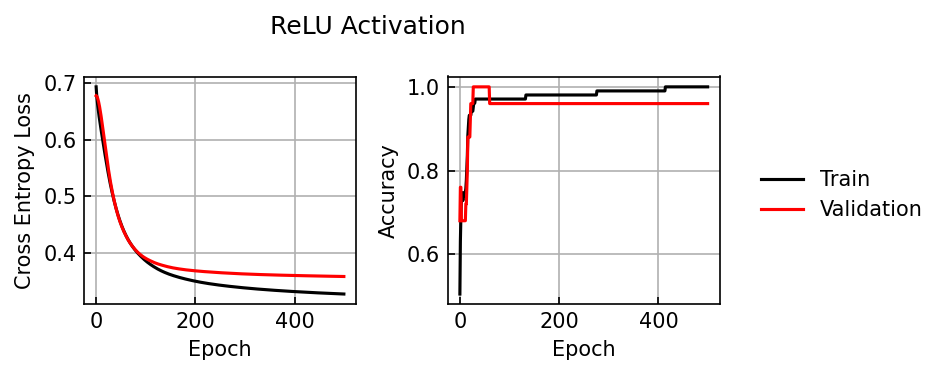

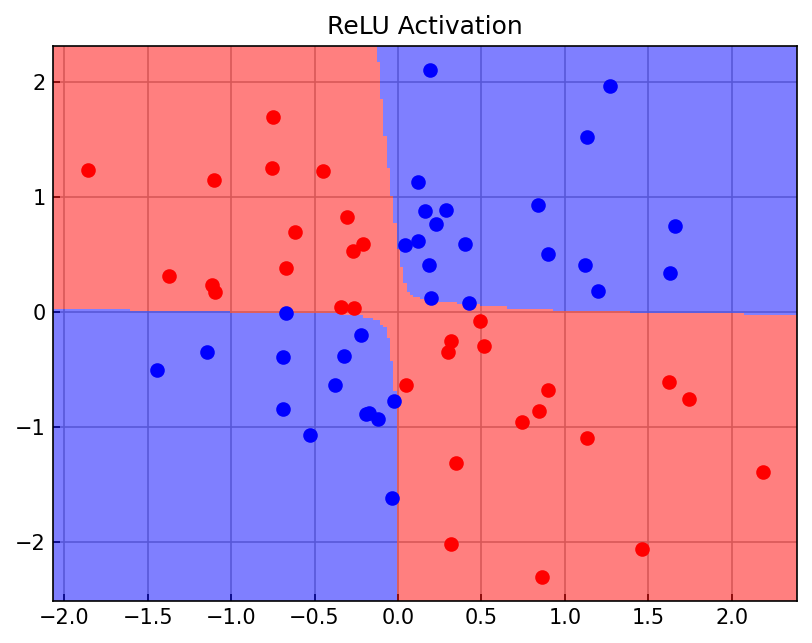

In [76]:
for label, model_type in zip(['Linear', 'Tanh', 'ReLU'],
                             [LinearModel, TanhModel, ReLUModel]):
    model = model_type(
        input_size=X.shape[1],
        hidden_size=128,
        output_size=2, # 2 classes
    ).to(device)

    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model, model_stats= train(model, loss_fn, optimizer, train_loader, val_loader)
    fig = loss_accuracy_plot(*model_stats)
    fig.suptitle(label + " Activation")
    plt.tight_layout()

    ax = plt.figure().gca()
    plot_decision_boundary(ax, X_test, y_test, model)
    ax.set_title(label + " Activation")
    plt.show()

## Deep MLP

In [77]:
class Model(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer1 = torch.nn.Linear(input_size, hidden_size)
        self.hidden_layer2 = torch.nn.Linear(hidden_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer1(x)
        x = torch.nn.functional.relu(x)
        x = self.hidden_layer2(x)
        x = torch.nn.functional.relu(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

model = Model(
    input_size=X.shape[1],
    hidden_size=128,
    output_size=2, # 2 classes
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model

Model(
  (hidden_layer1): Linear(in_features=2, out_features=128, bias=True)
  (hidden_layer2): Linear(in_features=128, out_features=128, bias=True)
  (output_layer): Linear(in_features=128, out_features=2, bias=True)
)

<Axes: >

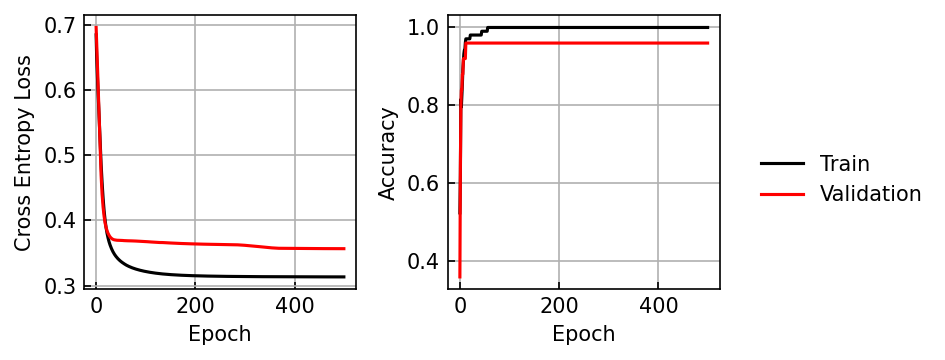

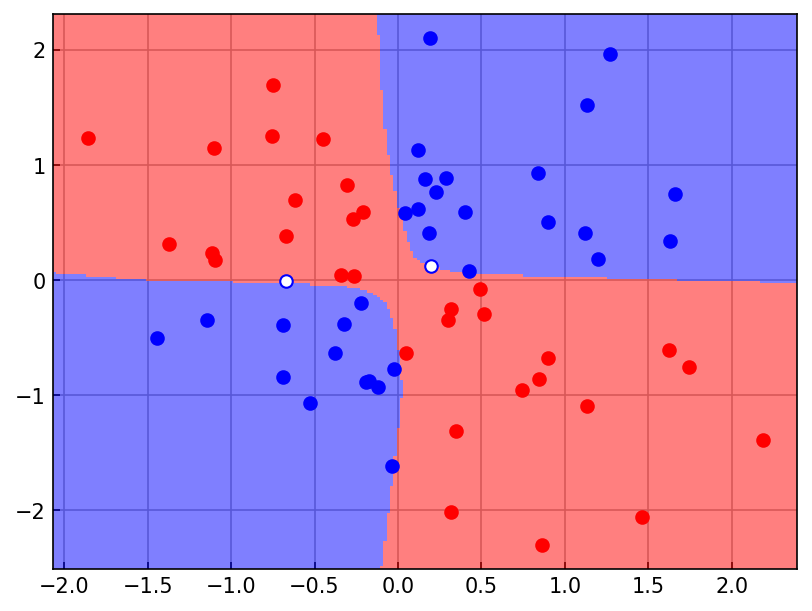

In [78]:
model, model_stats= train(model, loss_fn, optimizer, train_loader, val_loader)
loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)